In [1]:
import warnings
warnings.simplefilter(action='ignore')

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import scarches as sca
import sys

 captum (see https://github.com/pytorch/captum).


In [3]:
sc.set_figure_params(frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

In [4]:
!ls

Miniconda3-latest-Linux-x86_64.sh  cache  git	      output   sif
binary_matrix_summary.txt	   def	  miniconda3  scripts  snap


In [5]:
perc = 1
top_genes = 2000

adata_path = f'/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/anndata_inputs/adata_top_{perc}_top_genes_{top_genes}.h5ad'
model_path = f'/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/trained_models/model_{perc}_top_genes_{top_genes}_placeholder_condition'

In [6]:
adata = sc.read_h5ad(adata_path)

In [7]:
adata.obs["placeholder_condition"] = "placeholder"

In [8]:
vae = sca.models.EXPIMAP.load(model_path, adata, map_location='cpu')

AnnData object with n_obs × n_vars = 4544 × 1994
    obs: 'cancer_subtype', 'placeholder_condition'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_idx', 'counts_in_terms', 'gene_as_regulator'
    uns: 'cancer_subtype_colors', 'hvg', 'log1p', 'neighbors', 'nsd2_as_regulator', 'nsd2_as_target', 'pca', 'terms', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'I', 'PCs'
    layers: 'X_normalized', 'counts'
    obsp: 'connectivities', 'distances'

INITIALIZING NEW NETWORK..............
Encoder Architecture:
	Input Layer in, out and cond: 1994 300 1
	Hidden Layer 1 in/out: 300 300
	Hidden Layer 2 in/out: 300 300
	Mean/Var Layer in/out: 300 2212
Decoder Architecture:
	Masked linear layer in, ext_m, ext, cond, out:  2212 0 0 1 1994
	with hard mask.
Last Decoder layer: softmax


In [9]:
full_model = vae.model
encoder = full_model.encoder
decoder = full_model.decoder

In [10]:
conditions = adata.obs["placeholder_condition"].values
conditions

array(['placeholder', 'placeholder', 'placeholder', 'placeholder',
       'placeholder', 'placeholder', 'placeholder', ..., 'placeholder',
       'placeholder', 'placeholder', 'placeholder', 'placeholder',
       'placeholder', 'placeholder'], dtype=object)

In [11]:
# 1) pull out the exact mapping the model used
cond2idx = vae.model.condition_encoder  # {'placeholder': 0}

# 2) map your obs‐column
labels = adata.obs["placeholder_condition"].map(cond2idx).astype(int).values
#    → an array of shape (n_obs,) full of 0’ssss
# 3) make the PyTorch batch‐tensor
c_training = torch.tensor(labels, dtype=torch.long, device="cpu")
adata.obs['training_condition'] = c_training.numpy()

# 5) Now call your model:
data = torch.tensor(adata.X.toarray(), dtype=torch.float32)
#out = vae.model.full_forward(data, batch=c)
enc_out = vae.model.forward_encoder(x=data, batch=c_training, n_samples=1)
dec_out = vae.model.forward_decoder(z=enc_out['z1_mean'], batch=c_training, n_samples=1)

In [12]:
'''adata.obsm['z1_mean'] = enc_out['z1_mean'].detach().numpy()
sc.pp.neighbors(adata, use_rep='z1_mean')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cancer_subtype'])'''

"adata.obsm['z1_mean'] = enc_out['z1_mean'].detach().numpy()\nsc.pp.neighbors(adata, use_rep='z1_mean')\nsc.tl.umap(adata)\nsc.pl.umap(adata, color=['cancer_subtype'])"

In [13]:
'''sc.pp.neighbors(adata, use_rep='X')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cancer_subtype'])'''

"sc.pp.neighbors(adata, use_rep='X')\nsc.tl.umap(adata)\nsc.pl.umap(adata, color=['cancer_subtype'])"

In [14]:
'''adata.obsm['sample'] = dec_out['sample'].cpu().numpy()
sc.pp.neighbors(adata, use_rep='sample')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cancer_subtype'])'''

"adata.obsm['sample'] = dec_out['sample'].cpu().numpy()\nsc.pp.neighbors(adata, use_rep='sample')\nsc.tl.umap(adata)\nsc.pl.umap(adata, color=['cancer_subtype'])"

In [15]:
'''adata.obsm['dec_mean'] = dec_out['dec_mean'].detach().numpy()
sc.pp.neighbors(adata, use_rep='dec_mean')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cancer_subtype'])'''

"adata.obsm['dec_mean'] = dec_out['dec_mean'].detach().numpy()\nsc.pp.neighbors(adata, use_rep='dec_mean')\nsc.tl.umap(adata)\nsc.pl.umap(adata, color=['cancer_subtype'])"

In [ ]:
pert_gene_adata = vae.perturb_genes(
    adata=adata,
    genes=['Chga'],
    perturb_type='KO',
    group_key='cancer_subtype',
    category='CRPC-NE',
    obs_key='perturbation',
    condition_key='placeholder_condition',
    new_condition=None
)

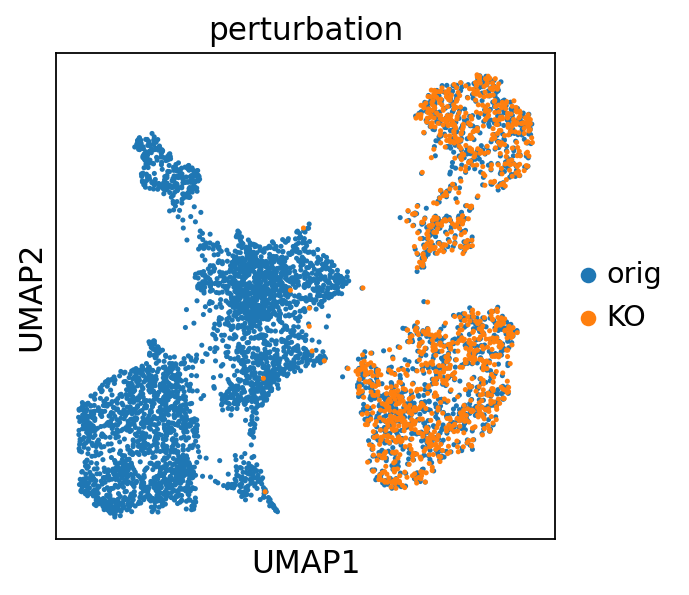

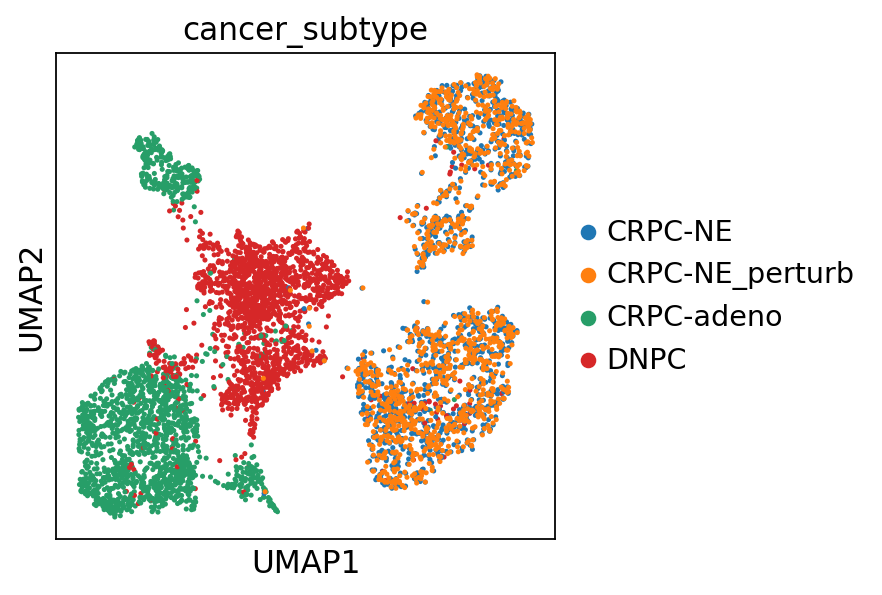

In [17]:
sc.pp.neighbors(pert_gene_adata, use_rep='z1_mean_all')
sc.tl.umap(pert_gene_adata)
sc.pl.umap(pert_gene_adata, color=['perturbation'])
sc.pl.umap(pert_gene_adata, color=['cancer_subtype'])

In [18]:
pert_gp_adata = vae.perturb_gps(
    adata=adata,
    programs=['Chga'],
    perturb_type='KO',
    group_key='cancer_subtype',
    category='CRPC-NE',
    obs_key='perturbation',
    condition_key='placeholder_condition',
    new_condition=None
)

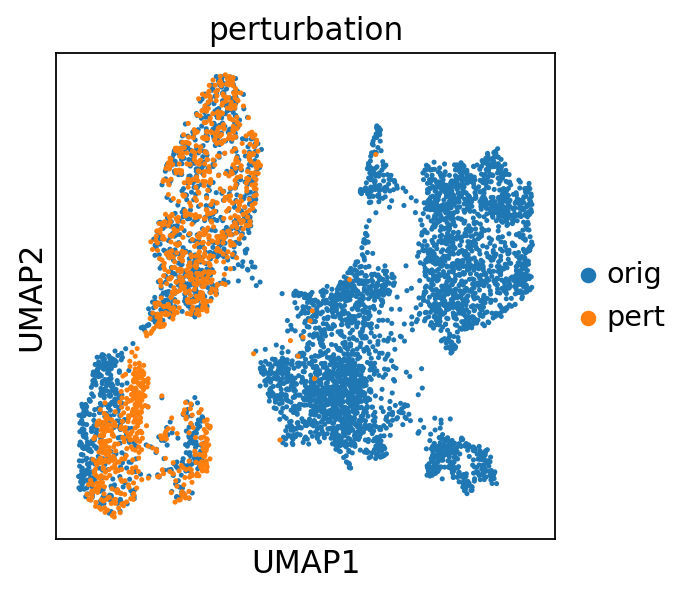

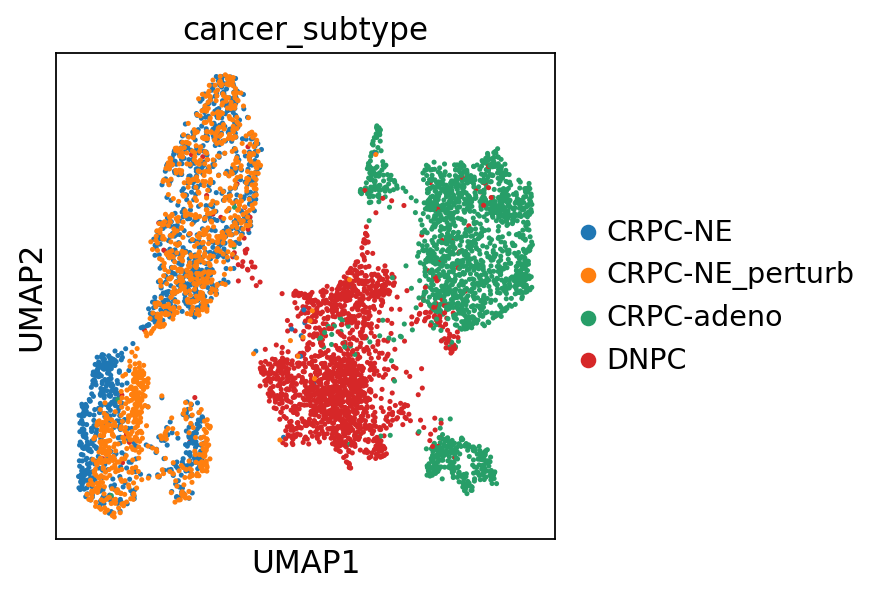

In [19]:
sc.pp.neighbors(pert_gp_adata, use_rep='X_expimap_pert')
sc.tl.umap(pert_gp_adata)
sc.pl.umap(pert_gp_adata, color=['perturbation'])
sc.pl.umap(pert_gp_adata, color=['cancer_subtype'])

In [20]:
pert_gene_adata

AnnData object with n_obs × n_vars = 5709 × 1994
    obs: 'cancer_subtype', 'placeholder_condition', 'training_condition', 'perturbation'
    uns: 'df_pert_genes_diffs', 'df_pert_programs_diffs', 'neighbors', 'umap', 'perturbation_colors', 'cancer_subtype_colors'
    obsm: 'X_pca', 'X_umap', 'z1_mean_all'
    layers: 'X_normalized', 'counts', 'perturbed_dec_mean'
    obsp: 'distances', 'connectivities'

In [24]:
pert_gene_adata.uns['df_pert_genes_diffs']

,gene_index,gene_name,raw_diff,abs_diff
0,1606,Chga,-1.962524e-03,1.962524e-03
1,1876,Ttr,-1.048535e-03,1.048535e-03
2,1989,mt-Cytb,-1.046404e-03,1.046404e-03
3,1306,Tmem158,-5.852552e-04,5.852552e-04
4,1218,Fxyd6,-5.536786e-04,5.536786e-04
...,...,...,...,...
1989,42,Ecel1,6.338087e-08,6.338087e-08
1990,1024,Col4a1,6.292248e-08,6.292248e-08
1991,1407,Gm45716,6.259506e-08,6.259506e-08
1992,1459,Inhba,-3.009336e-08,3.009336e-08


In [25]:
pert_gene_adata.uns['df_pert_programs_diffs']

,program_index,program_name,raw_diff,abs_diff
0,236,Chga,-3.872828e-01,3.872828e-01
1,382,Efemp1,-8.149445e-02,8.149445e-02
2,47,Ajuba,-6.002200e-02,6.002200e-02
3,682,Hist3h2ba,-5.729270e-02,5.729270e-02
4,1288,Ppie,-5.679381e-02,5.679381e-02
...,...,...,...,...
2207,1421,Runx2,1.422741e-06,1.422741e-06
2208,768,Ikzf2,-1.023405e-06,1.023405e-06
2209,1335,Rabgef1,8.311326e-07,8.311326e-07
2210,1725,Trp53bp2,4.404865e-07,4.404865e-07


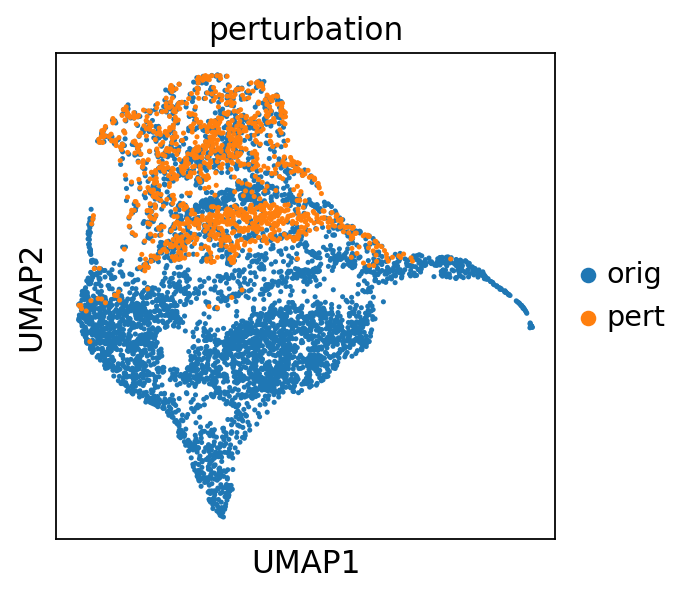

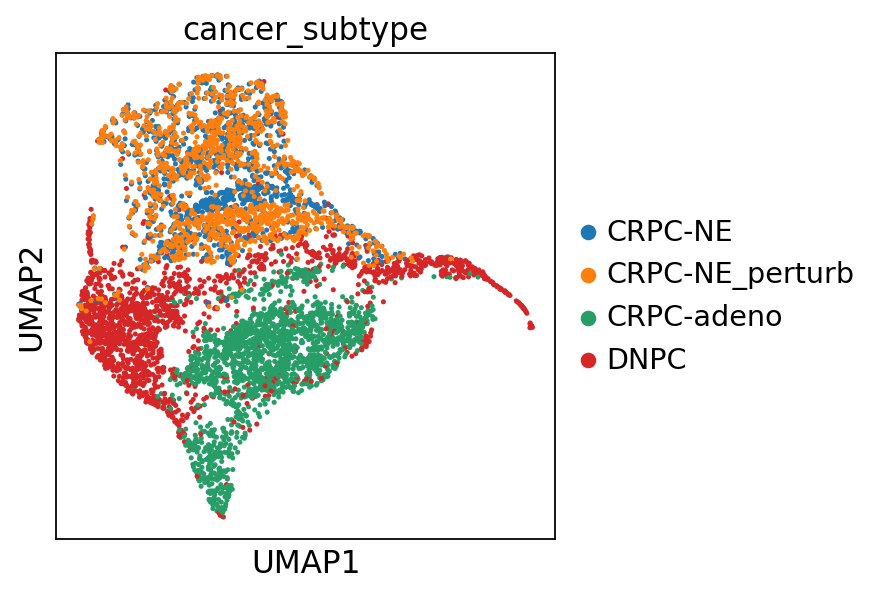

In [21]:
sc.pp.neighbors(pert_gp_adata, use_rep='X')
sc.tl.umap(pert_gp_adata)
sc.pl.umap(pert_gp_adata, color=['perturbation'])
sc.pl.umap(pert_gp_adata, color=['cancer_subtype'])